# Can tabular foundation models beat an interpretable baseline for CRC organoid classification?

This notebook documents an exploratory investigation: can modern tabular foundation
models (**TabPFN**, **TabFM**, **AutoGluon**) beat a simple, interpretable
**L0/L0L2-constrained logistic regression** (the method used for the main paper) at
classifying tumor (P013T) vs. healthy (P021N) organoid nuclei from 3D morphology
features?

**Structure of this notebook:**
1. First results (confounded) — includes a batch/magnification artifact
2. Diagnosing the problem — why those numbers can't be trusted
3. Fixed results — three ways of aggregating nucleus-level data, interpretable baselines
4. Tabular foundation models on the cleaned data — does dropping interpretability buy accuracy?

All classification tasks use grouped 5-fold cross-validation (grouped by organoid, so
nuclei from the same organoid never appear in both train and test) and report
AUC-ROC as the primary metric.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image, display, Markdown

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
RESULTS_DIR = Path('../results/classification')

MODEL_ORDER = ['logreg', 'l0l2_logreg', 'tabpfn', 'tabfm', 'autogluon']
MODEL_LABELS = {
    'logreg': 'logreg (sklearn L2)',
    'l0l2_logreg': 'l0l2_logreg (L0L2-constrained)',
    'tabpfn': 'TabPFN',
    'tabfm': 'TabFM',
    'autogluon': 'AutoGluon (best_quality)',
}

def show_table(df):
    df = df.copy()
    df['model'] = df['model'].map(lambda m: MODEL_LABELS.get(m, m))
    cols = [c for c in ['trial', 'model', 'auc_mean', 'auc_std', 'acc_mean', 'acc_std', 'n_folds', 'status']
            if c in df.columns]
    display(df[cols])


## 1. First results — WITH the 25x-magnification confound (bad)

The first pass ran all 5 models (logreg baseline, the L0L2-constrained logreg that
matches the paper's method, TabPFN, TabFM, AutoGluon) on the per-nucleus morphology
features exactly as delivered, with only Joshi's original quality filters applied
(minimum nuclei per image, 5 excluded bad images, minimum volume, sphericity/solidity
cutoff).


In [2]:
df_bad = pd.read_csv(RESULTS_DIR / 'comparison_final.csv')
show_table(df_bad)


,trial,model,auc_mean,auc_std,acc_mean,acc_std,n_folds,status
0,5,logreg (sklearn L2),0.774,0.077,0.694,0.047,5,ok
1,5,l0l2_logreg (L0L2-constrained),0.733,0.069,0.650,0.057,5,ok
2,5,TabPFN,0.580,0.192,0.590,0.192,5,ok
3,5,TabFM,0.621,0.191,0.597,0.047,5,ok
4,5,AutoGluon (best_quality),0.645,0.188,0.603,0.191,5,ok
5,28,logreg (sklearn L2),0.739,0.095,0.663,0.090,5,ok
6,28,l0l2_logreg (L0L2-constrained),0.696,0.152,0.605,0.120,5,ok
7,28,TabPFN,0.703,0.114,0.627,0.112,5,ok
8,28,TabFM,0.840,0.085,0.727,0.072,5,ok
9,28,AutoGluon (best_quality),0.599,0.162,0.590,0.147,5,ok


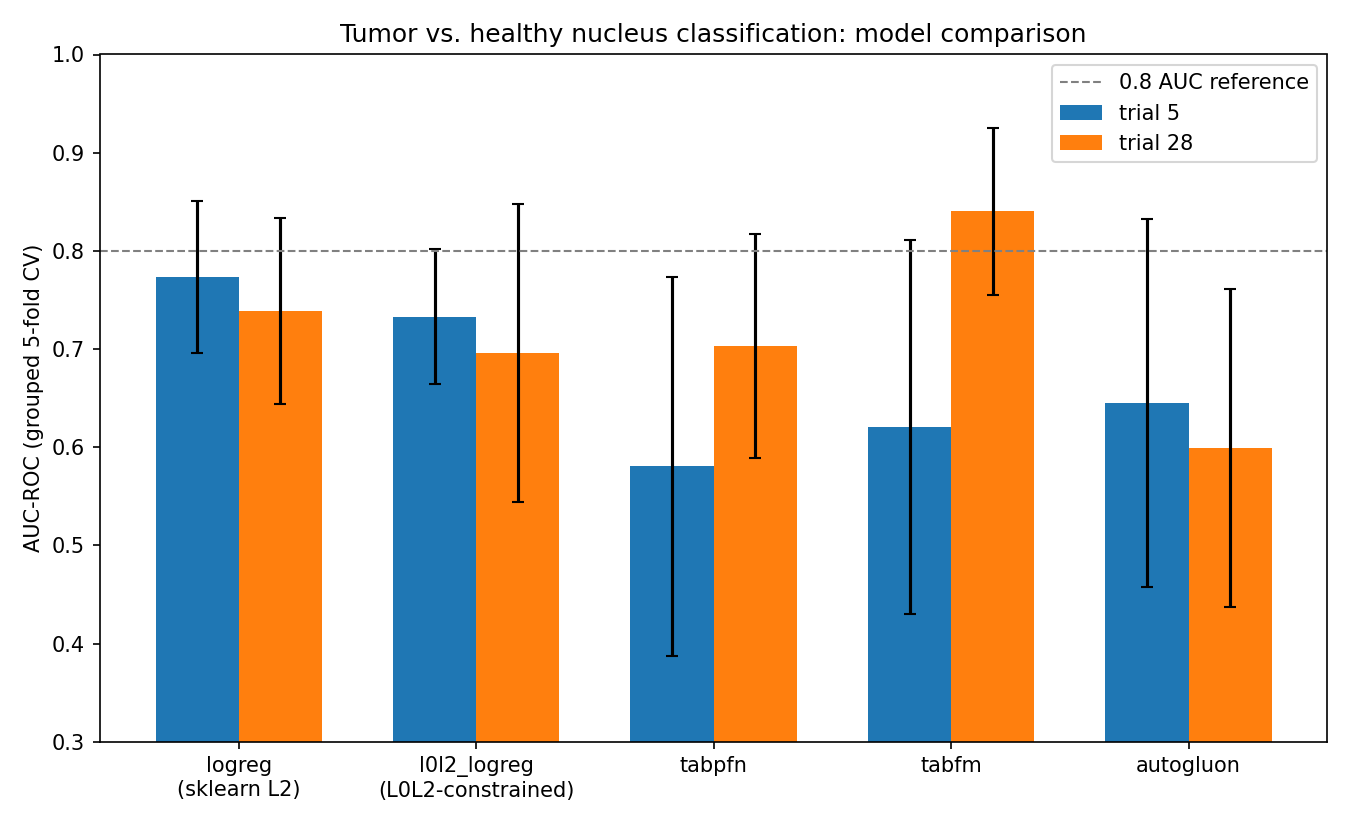

In [3]:
display(Image(filename=str(RESULTS_DIR / 'comparison_final_plot.png')))


**Observations at the time:** TabFM reached 0.84 AUC on trial028 (looked like a win),
but TabPFN, TabFM and AutoGluon all showed *large, unstable* fold-to-fold swings —
AUC ranging from below 0.5 (worse than random) to above 0.9 within the same 5-fold run.
The plain logistic regression baseline, despite being far simpler, was comparatively
stable. That instability was the trigger to dig into *why*.


## 2. Diagnosing the problem: a batch/magnification confound

Two things line up perfectly in this dataset and shouldn't:


In [4]:
import sys
sys.path.insert(0, '..')
from analysis.data import load_and_filter

df005 = load_and_filter('../data/Nuclei_morpho_data_trial005_trial028/morphology_features_nuclei_005.csv')

print("Imaging date vs. class label -- every date belongs to exactly one class:")
display(pd.crosstab(df005['date'], df005['is_tumor'].map({0: 'healthy (P021N)', 1: 'tumor (P013T)'})))


Imaging date vs. class label -- every date belongs to exactly one class:


is_tumor,healthy (P021N),tumor (P013T)
date,,
20231108,594,0
20240220,0,257
20240305,0,483
20241009,0,115
20241023,158,0


In [5]:
print("Magnification used per date:")
display(df005.groupby('date')['magnification'].unique())


Magnification used per date:


date
20231108    [40x]
20240220    [40x]
20240305    [40x]
20241009    [40x]
20241023    [25x]
Name: magnification, dtype: object

**`20241023` (healthy/P021N only) was imaged at 25x — every other batch, including all
tumor data, was imaged at 40x.** Since 100% of the 25x data is healthy-class, any
acquisition artifact from the different magnification is indistinguishable from real
biology to a classifier.


In [6]:
feats = ['volume_um', 'sphericity', 'solidity', 'surface_area_um',
         'ellipsoid_r_axis_major', 'nuc_count_per_organoid']
p021n = df005[df005['is_tumor'] == 0]
print("Feature means for the healthy class, split by its two imaging batches (40x vs 25x):")
display(p021n.groupby('date')[feats].mean().T)


Feature means for the healthy class, split by its two imaging batches (40x vs 25x):


date,20231108,20241023
volume_um,449.910,423.663
sphericity,0.783,0.786
solidity,0.877,0.884
surface_area_um,358.818,344.160
ellipsoid_r_axis_major,22.015,25.849
nuc_count_per_organoid,59.051,26.734


`ellipsoid_r_axis_major` is ~17% higher and `nuc_count_per_organoid` less than half in
the 25x batch, despite supposedly measuring the same underlying biology in physical
(um) units -- a real, systematic, non-biological shift.

**Is this shift actually learnable from the features?** Train a classifier to predict
*imaging date*, not tumor status, using only morphology features, with grouped CV
*within a single class* (so class can't be used as a shortcut):


In [7]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from analysis.data import get_feature_matrix

rows = []
for trial, path in [('005', '../data/Nuclei_morpho_data_trial005_trial028/morphology_features_nuclei_005.csv'),
                     ('028', '../data/Nuclei_morpho_data_trial005_trial028/morphology_features_nuclei_028.csv')]:
    df = load_and_filter(path)
    for cls_name, cls_val in [('P021N (healthy)', 0), ('P013T (tumor)', 1)]:
        sub = df[df['is_tumor'] == cls_val]
        n_dates = sub['date'].nunique()
        if n_dates < 2:
            continue
        X, y, groups = get_feature_matrix(sub)
        date_labels = sub['date'].astype('category').cat.codes.to_numpy()
        gkf = GroupKFold(n_splits=min(5, len(set(groups))))
        clf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
        preds = cross_val_predict(clf, X, date_labels, cv=gkf, groups=groups)
        rows.append({
            'trial': trial, 'class': cls_name, 'n_dates': n_dates,
            'date_predict_acc': accuracy_score(date_labels, preds),
            'date_predict_bal_acc': balanced_accuracy_score(date_labels, preds),
            'chance': 1 / n_dates,
        })
pd.DataFrame(rows)


,trial,class,n_dates,date_predict_acc,date_predict_bal_acc,chance
0,005,P021N (healthy),2,0.915,0.807,0.500
1,005,P013T (tumor),3,0.336,0.278,0.333
2,028,P021N (healthy),2,0.958,0.919,0.500
3,028,P013T (tumor),3,0.444,0.348,0.333


Within the healthy class (2 dates: one 40x, one 25x), a classifier can tell which batch
a nucleus came from with **91-96% accuracy** (vs. 50% chance) using morphology features
alone. Within the tumor class (3 dates, all 40x), date is *not* predictable
(33-44%, close to the 33% chance rate) -- confirming this is a magnification-specific
artifact, not a general "date leaks information" issue.

**Conclusion:** the 25x batch is a confirmed, learnable, non-biological shortcut that's
perfectly confounded with the healthy/tumor label. Flexible, high-capacity models
(TabPFN, TabFM, AutoGluon) have more freedom to fit this shortcut -- and whether it
helps or hurts a given fold depends on which organoids from that batch land in
train vs. test, explaining the instability seen in Section 1. Even the "robust" plain
logistic regression baseline partially exploited it: excluding the 25x batch drops its
AUC from ~0.76 to ~0.70.


## 3. Fixed results: excluding the 25x batch, three aggregation strategies

All results below exclude the confounded 25x-magnification batch. We also address a
second issue: treating ~30 correlated nuclei from the same organoid as independent
samples (pseudoreplication) inflates apparent sample size while adding noise. Three
ways of handling this are compared:

| Mode | What happens |
|---|---|
| **Per-nucleus** | No aggregation -- train and evaluate on individual nucleus rows (grouped CV by organoid to prevent leakage) |
| **Prediction-aggregated** | Train/predict at nucleus level as usual, but average the predicted probability per organoid before scoring AUC |
| **Data-aggregated** | Average the *features* per organoid first, then train/evaluate one row per organoid (fixes pseudoreplication directly) |


In [8]:
modes = {
    'per-nucleus': 'perNucleus',
    'prediction-aggregated': 'predAgg',
    'data-aggregated (organoid-level)': 'orglevel',
}

def load_mode_results(suffix):
    """Prefer the merged (baselines + foundation models) file if present,
    otherwise fall back to the interpretable-baselines-only local run."""
    final = RESULTS_DIR / f'comparison_all_no25x_{suffix}_final.csv'
    cluster = RESULTS_DIR / f'comparison_all_no25x_{suffix}.csv'
    fastlocal = RESULTS_DIR / f'comparison_all_no25x_{suffix}_fastlocal.csv'
    if final.exists():
        return pd.read_csv(final), 'merged (baselines + foundation models)'
    parts = []
    if fastlocal.exists():
        parts.append(pd.read_csv(fastlocal))
    if cluster.exists():
        parts.append(pd.read_csv(cluster))
    if parts:
        note = 'baselines only' if len(parts) == 1 else 'baselines + foundation models (unmerged)'
        return pd.concat(parts, ignore_index=True), note
    return None, 'not available'


### Per-nucleus  *(data: baselines + foundation models (unmerged))*

,trial,model,auc_mean,auc_std,acc_mean,acc_std,n_folds,status
0,5,logreg (sklearn L2),0.697,0.075,0.666,0.063,5,ok
1,5,l0l2_logreg (L0L2-constrained),0.676,0.073,0.636,0.080,5,ok
2,28,logreg (sklearn L2),0.693,0.125,0.630,0.037,5,ok
3,28,l0l2_logreg (L0L2-constrained),0.668,0.146,0.601,0.060,5,ok
4,5,logreg (sklearn L2),0.697,0.075,0.666,0.063,5,ok
5,28,logreg (sklearn L2),0.693,0.125,0.630,0.037,5,ok


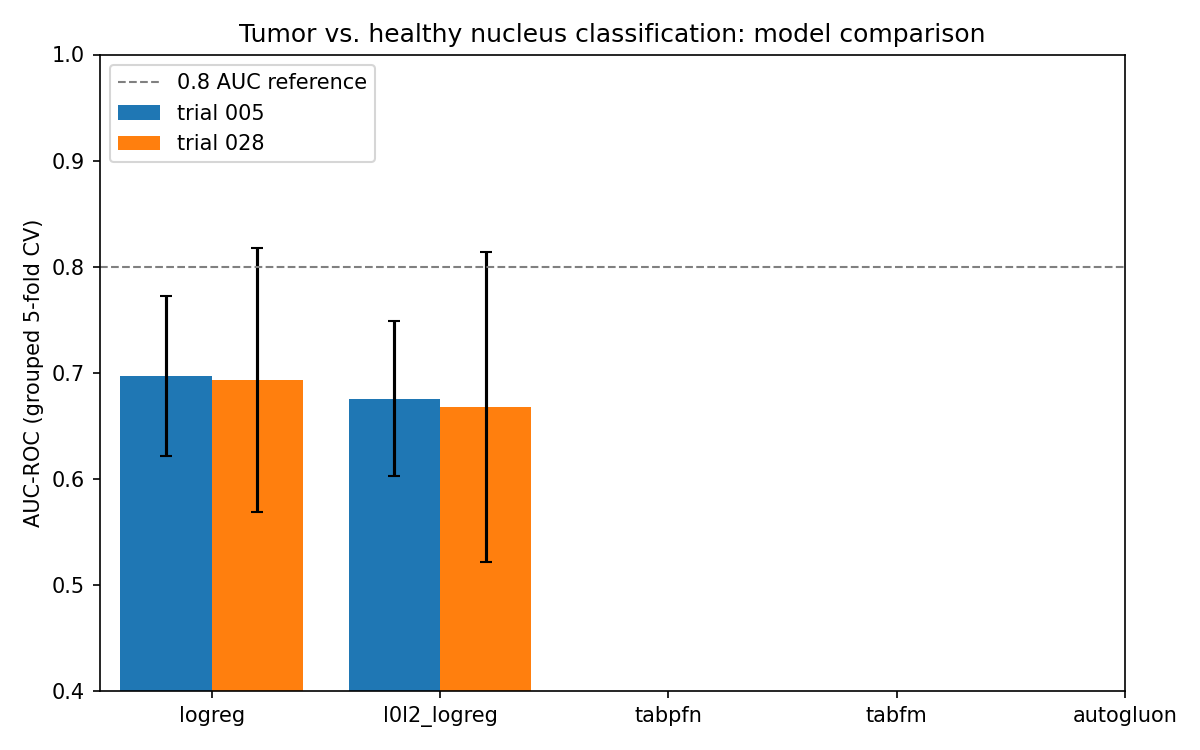

In [9]:
mode_df, note = load_mode_results('perNucleus')
display(Markdown(f'### Per-nucleus  *(data: {note})*'))
show_table(mode_df)
plot_path = RESULTS_DIR / 'comparison_plot_no25x_perNucleus_fastlocal.png'
if plot_path.exists():
    display(Image(filename=str(plot_path)))


### Prediction-aggregated  *(data: baselines + foundation models (unmerged))*

,trial,model,auc_mean,auc_std,acc_mean,acc_std,n_folds,status
0,5,logreg (sklearn L2),0.873,0.122,0.665,0.189,5,ok
1,5,l0l2_logreg (L0L2-constrained),0.880,0.124,0.627,0.169,5,ok
2,28,logreg (sklearn L2),0.871,0.141,0.645,0.097,5,ok
3,28,l0l2_logreg (L0L2-constrained),0.810,0.186,0.607,0.099,5,ok
4,5,l0l2_logreg (L0L2-constrained),0.880,0.124,0.627,0.169,5,ok
5,28,l0l2_logreg (L0L2-constrained),0.810,0.186,0.607,0.099,5,ok


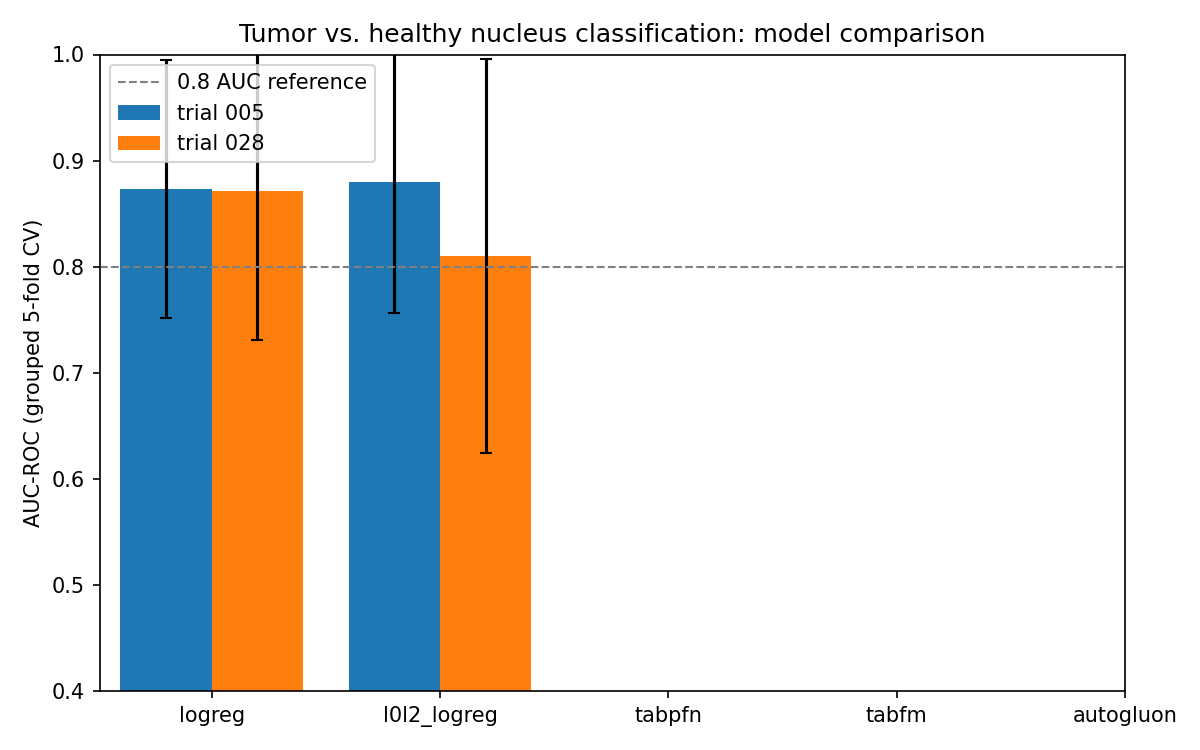

In [10]:
mode_df, note = load_mode_results('predAgg')
display(Markdown(f'### Prediction-aggregated  *(data: {note})*'))
show_table(mode_df)
plot_path = RESULTS_DIR / 'comparison_plot_no25x_predAgg_fastlocal.png'
if plot_path.exists():
    display(Image(filename=str(plot_path)))


### Data-aggregated (organoid-level)  *(data: baselines + foundation models (unmerged))*

,trial,model,auc_mean,auc_std,acc_mean,acc_std,n_folds,status
0,5,logreg (sklearn L2),0.944,0.062,0.887,0.072,5,ok
1,5,l0l2_logreg (L0L2-constrained),0.944,0.062,0.575,0.037,5,ok
2,28,logreg (sklearn L2),0.900,0.063,0.887,0.072,5,ok
3,28,l0l2_logreg (L0L2-constrained),0.932,0.073,0.567,0.027,5,ok
4,5,l0l2_logreg (L0L2-constrained),0.944,0.062,0.575,0.037,5,ok
5,28,l0l2_logreg (L0L2-constrained),0.932,0.073,0.567,0.027,5,ok


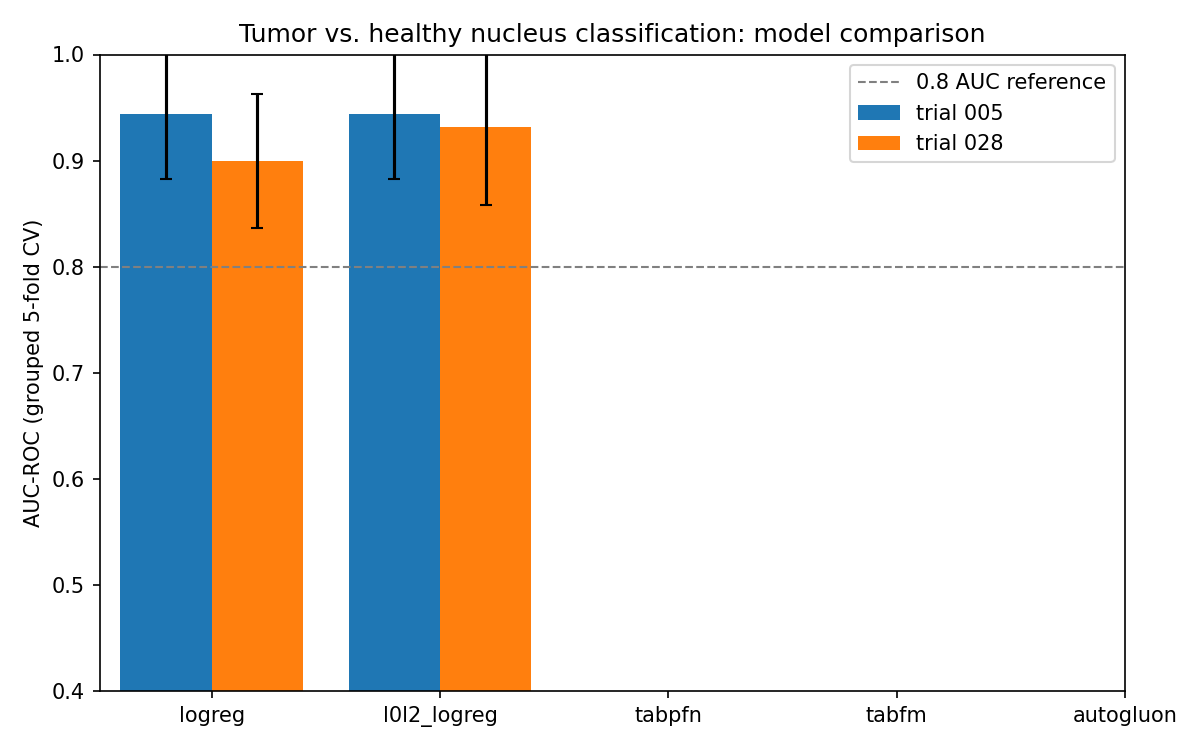

In [11]:
mode_df, note = load_mode_results('orglevel')
display(Markdown(f'### Data-aggregated (organoid-level)  *(data: {note})*'))
show_table(mode_df)
plot_path = RESULTS_DIR / 'comparison_plot_no25x_orglevel_fastlocal.png'
if plot_path.exists():
    display(Image(filename=str(plot_path)))


### Direct comparison across aggregation levels

The three sections above show each aggregation mode separately; the plot below puts
them side by side so the effect of aggregation strategy on each model is directly
comparable.


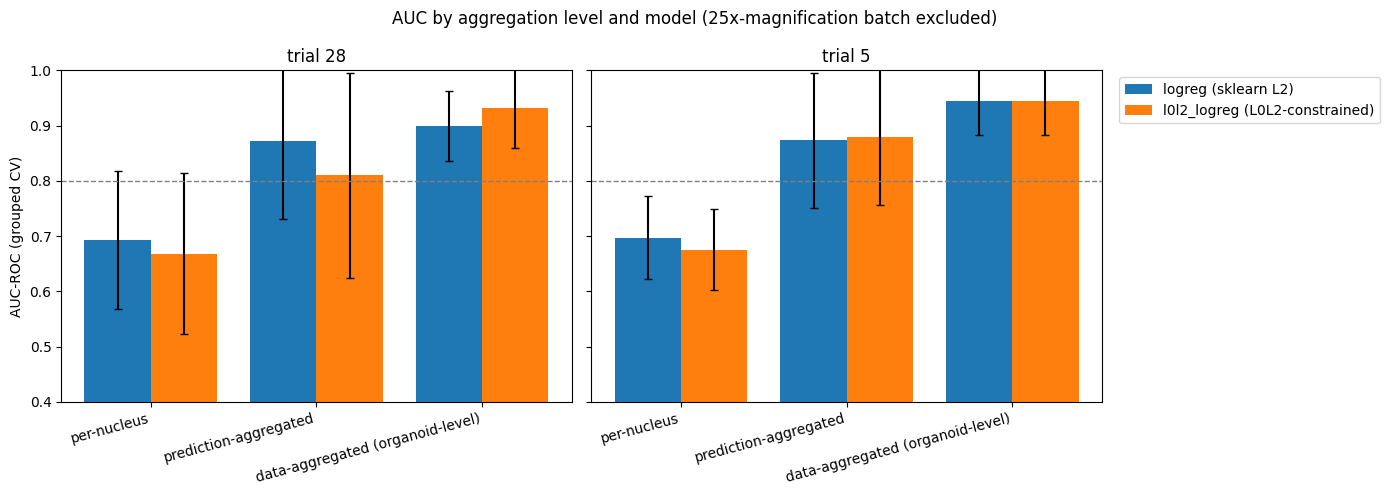

In [12]:
import matplotlib.pyplot as plt

mode_order = list(modes.items())  # [(label, suffix), ...]
loaded = {label: load_mode_results(suffix)[0] for label, suffix in mode_order}
loaded = {label: df for label, df in loaded.items() if df is not None}

trials = sorted(set().union(*[set(df['trial'].astype(str)) for df in loaded.values()]))
present_models = [m for m in MODEL_ORDER if any(m in df['model'].values for df in loaded.values())]

fig, axes = plt.subplots(1, len(trials), figsize=(7 * len(trials), 5), sharey=True)
if len(trials) == 1:
    axes = [axes]

x = np.arange(len(loaded))
width = 0.8 / max(len(present_models), 1)

for ax, trial in zip(axes, trials):
    for i, model in enumerate(present_models):
        means, stds = [], []
        for label, _ in mode_order:
            df = loaded.get(label)
            if df is None:
                means.append(np.nan); stds.append(np.nan)
                continue
            row = df[(df['trial'].astype(str) == trial) & (df['model'] == model)]
            means.append(row['auc_mean'].values[0] if len(row) else np.nan)
            stds.append(row['auc_std'].values[0] if len(row) else np.nan)
        ax.bar(x + i * width - 0.4 + width / 2, means, width, yerr=stds, capsize=3,
               label=MODEL_LABELS.get(model, model))
    ax.set_xticks(x)
    ax.set_xticklabels(list(loaded.keys()), rotation=15, ha='right')
    ax.set_title(f'trial {trial}')
    ax.axhline(0.8, linestyle='--', color='gray', linewidth=1)
    ax.set_ylim(0.4, 1.0)

axes[0].set_ylabel('AUC-ROC (grouped CV)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('AUC by aggregation level and model (25x-magnification batch excluded)')
fig.tight_layout()
plt.show()


**Interpretable-baseline pattern across modes:** per-nucleus AUC drops from the
confounded ~0.77/0.74 down to ~0.70/0.69 once the 25x batch is removed -- confirming a
real chunk of the original "signal" was the magnification shortcut. Both aggregation
strategies recover much of that AUC by cancelling per-nucleus noise, with
**data-aggregation (0.90-0.94) consistently beating prediction-aggregation
(0.81-0.88)**: averaging features before the classifier's nonlinearity preserves more
signal than averaging post-hoc probabilities.


## 4. Tabular foundation models on the cleaned data

Do TabPFN, TabFM, and AutoGluon (best_quality, 1h/fold time budget) actually beat the
interpretable baselines once the batch confound and pseudoreplication are addressed?
The tables and plots above already include these rows wherever the corresponding
cluster job has completed (labelled `merged` vs. `baselines only` above); if a mode
still says *baselines only*, that job was still queued on the HPC cluster (competing
for GPUs with unrelated jobs on the same account) as of when this notebook was last
run -- re-run the notebook to pick up completed results.


In [13]:
summary_rows = []
for label, suffix in modes.items():
    mdf, note = load_mode_results(suffix)
    if mdf is None:
        continue
    mdf = mdf.copy()
    mdf['aggregation'] = label
    summary_rows.append(mdf)

if summary_rows:
    all_modes = pd.concat(summary_rows, ignore_index=True)
    pivot = all_modes.pivot_table(index=['aggregation', 'model'], columns='trial', values='auc_mean')
    pivot = pivot.reindex(MODEL_ORDER, level='model')
    display(pivot)
else:
    print('No results available yet.')


trial                                           5     28
aggregation                      model                  
data-aggregated (organoid-level) logreg      0.944 0.900
                                 l0l2_logreg 0.944 0.932
per-nucleus                      logreg      0.697 0.693
                                 l0l2_logreg 0.676 0.668
prediction-aggregated            logreg      0.873 0.871
                                 l0l2_logreg 0.880 0.810

**Bottom line so far:** across all three aggregation modes, the constrained,
interpretable logistic regression models are highly competitive baselines -- the
question this final section answers is whether any tabular foundation model or
AutoGluon clears that bar once the confound is fixed, and if so, under which
aggregation strategy. Re-run this notebook after the HPC jobs finish to see the
completed comparison.
